In [53]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
import cmocean

In [54]:
path_input = '../data/'
path_output = '../figures/'

In [55]:
def compute_pdf(var, bins):

    """
    Purpose: Compute the probability density function (pdf) of a given 2D or 1D field
    ---------
    Inputs:
    ---------
    var: the snapshot or the array for the pdf
    bins: the bins axis

    
    Outputs:
    ---------
    pdf: the computed pdf in [%]
    bin_centers: the bin axis associated with the pdf
    """


    var_finite = var[np.isfinite(var)]
    hist_var, _ = np.histogram(var_finite, bins=bins)
    pdf_var = hist_var / hist_var.sum() * 100


    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return pdf_var, bin_centers

In [56]:

date_case1 = np.datetime64('2024-07-06T00:00:00.000000000') # time spotted
date_case2 = np.datetime64('2023-09-17T00:00:00.000000000') # time spotted

props = dict(boxstyle='round', facecolor='w')
prop2s = dict(boxstyle='square', facecolor='white', alpha=0.8)

In [57]:
ds_ssha_case1 = xr.open_dataset(path_input + 'trapped_swot_eddy.nc')
ds_ssha_case2 = xr.open_dataset(path_input + 'strong_swot_eddy.nc')

ds_ameda_case_1 = xr.open_dataset(path_input + 'eddy_contours_trapped_eddies.nc')
ds_ameda_case_2 = xr.open_dataset(path_input + 'eddy_contours_strong_eddy.nc')

ds_stats_eddies = xr.open_dataset(path_input + 'paired_eddy_param.nc')
ds_stats_bigeddies = xr.open_dataset(path_input + 'paired_eddy_param_bigeddies.nc')


In [58]:
dR = (ds_stats_eddies.rmax_paired_swot - ds_stats_eddies.rmax_paired_duacs)
dE = (ds_stats_eddies.eke_paired_swot - ds_stats_eddies.eke_paired_duacs)


dR_bigeddies = (ds_stats_bigeddies.rmax_paired_swot - ds_stats_bigeddies.rmax_paired_duacs)
dE_bigeddies = (ds_stats_bigeddies.eke_paired_swot - ds_stats_bigeddies.eke_paired_duacs)


bin_rmax = np.linspace(0, 100, 30)
pdf_swot_rmax, bin_centered_rmax = compute_pdf(ds_stats_eddies.rmax_paired_swot, bin_rmax)
pdf_duacs_rmax, bin_centered_rmax = compute_pdf(ds_stats_eddies.rmax_paired_duacs, bin_rmax)
pdf_duacs_rmax_bigeddies, bin_centered_rmax = compute_pdf(ds_stats_bigeddies.rmax_paired_swot, bin_rmax)




<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48050/3100430548.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude [$^{\circ}$N]')
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48050/3100430548.py:41: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('Longitude [$^{\circ}$E]')
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48050/3100430548.py:42: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Latitude [$^{\circ}$N]')
/var/folders/bx/gz6w8d_533x2h1m1pq2pt88m0000gn/T/ipykernel_48050/3100430548.py:56: S

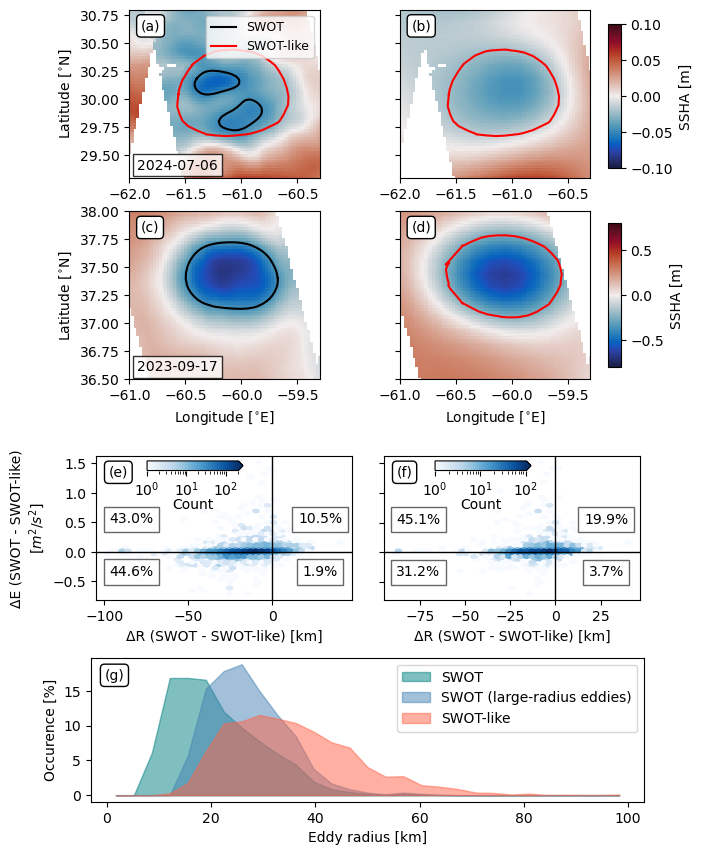

In [59]:

fig, axes = plt.subplots(ncols = 2, nrows = 2)
ax = axes[0][0]
p1 = ax.pcolormesh(ds_ssha_case1.longitude, ds_ssha_case1.latitude, ds_ssha_case1.ssha_swot, vmin = -.1, vmax = .1, cmap = cmocean.cm.balance)
ax.plot(ds_ameda_case_1.x_eddy_swot_1, ds_ameda_case_1.y_eddy_swot_1, color = 'k', label = 'SWOT')
ax.plot(ds_ameda_case_1.x_eddy_swot_2, ds_ameda_case_1.y_eddy_swot_2, color = 'k')
ax.plot(ds_ameda_case_1.x_eddy_duacs, ds_ameda_case_1.y_eddy_duacs, color = 'r', label = 'SWOT-like')
ax.text(0.04, 0.05, f'{np.datetime_as_string(date_case1, unit='D')}',
     transform = ax.transAxes, bbox = prop2s)
ax.set_ylim([29.3, 30.8])
ax.set_xlim([-62, -60.3])
ax.set_aspect('equal', 'box')
ax.text(0.06, 0.88, '(a)',
     transform = ax.transAxes, bbox = props)
ax.set_ylabel('Latitude [$^{\circ}$N]')
ax.legend(loc = 1, fontsize = 9)
ax = axes[0][1]
ax.pcolormesh(ds_ssha_case1.longitude, ds_ssha_case1.latitude, ds_ssha_case1.ssha_duacs, vmin = -.1, vmax = .1, cmap = cmocean.cm.balance)
ax.plot(ds_ameda_case_1.x_eddy_duacs, ds_ameda_case_1.y_eddy_duacs, color = 'r', label = 'SWOT-like')
ax.set_ylim([29.3, 30.8])
ax.set_xlim([-62, -60.3])
ax.set_yticklabels('')


cax = fig.add_axes([.9, .55, 0.02, 0.3])
plt.colorbar(p1, cax = cax, orientation = 'vertical', label = 'SSHA [m]')
ax.set_aspect('equal', 'box')
ax.text(0.06, 0.88, '(b)',
     transform = ax.transAxes, bbox = props)


ax = axes[1][0]
ax.pcolormesh(ds_ssha_case2.longitude, ds_ssha_case2.latitude, ds_ssha_case2.ssha_swot, vmin = -.8, vmax = .8, cmap = cmocean.cm.balance)
ax.plot(ds_ameda_case_2.x_eddy_swot_1, ds_ameda_case_2.y_eddy_swot_1, color = 'k', label = 'SWOT')
ax.text(0.04, 0.05, f'{np.datetime_as_string(date_case2, unit='D')}',
     transform = ax.transAxes, bbox = prop2s)
ax.set_ylim([36.5, 38])
ax.set_xlim([-61, -59.3])
ax.set_aspect('equal', 'box')
ax.text(0.06, 0.88, '(c)',
     transform = ax.transAxes, bbox = props)
ax.set_xlabel('Longitude [$^{\circ}$E]')
ax.set_ylabel('Latitude [$^{\circ}$N]')

ax = axes[1][1]
p1 = ax.pcolormesh(ds_ssha_case2.longitude, ds_ssha_case2.latitude, ds_ssha_case2.ssha_duacs, vmin = -.8, vmax = .8, cmap = cmocean.cm.balance)
ax.plot(ds_ameda_case_2.x_eddy_duacs, ds_ameda_case_2.y_eddy_duacs, color = 'r')
ax.set_ylim([36.5, 38])
ax.set_xlim([-61, -59.3])
ax.set_yticklabels('')
cax = fig.add_axes([.9, .135, 0.02, 0.3])
plt.colorbar(p1, cax = cax, orientation = 'vertical', label = 'SSHA [m]')
ax.set_aspect('equal', 'box')
ax.text(0.06, 0.88, '(d)',
     transform = ax.transAxes, bbox = props)

ax.set_xlabel('Longitude [$^{\circ}$E]')

ax_bottom_stat = fig.add_axes([.1, -.35, .4, .3])

# ax = axes[2][0]
ax = ax_bottom_stat
hb = ax.hexbin(dR, dE, gridsize=40, cmap='Blues', norm=matplotlib.colors.LogNorm())

# Axes
ax.axhline(0, color='k', lw=1)
ax.axvline(0, color='k', lw=1)

ax.set_xlabel('ΔR (SWOT - SWOT-like) [km]')
ax.set_ylabel('ΔE (SWOT - SWOT-like)\n[$m^{2}/s^{2}$]')

# --- Compute percentages
total = len(dR)

q1 = np.sum((dR > 0) & (dE > 0)) / total * 100  # top-right
q2 = np.sum((dR < 0) & (dE > 0)) / total * 100  # top-left
q3 = np.sum((dR < 0) & (dE < 0)) / total * 100  # bottom-left
q4 = np.sum((dR > 0) & (dE < 0)) / total * 100  # bottom-right

# --- Axis limits (for positioning text)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# --- Add text annotations
bbox = dict(facecolor='white', alpha=0.6, edgecolor='k')

ax.text(0.6*xmax, 0.3*ymax, f"{q1:.1f}%", bbox=bbox, ha='center')
ax.text(0.8*xmin, 0.3*ymax, f"{q2:.1f}%", bbox=bbox, ha='center')
ax.text(0.8*xmin, 0.5*ymin, f"{q3:.1f}%", bbox=bbox, ha='center')
ax.text(0.6*xmax, 0.5*ymin, f"{q4:.1f}%", bbox=bbox, ha='center')

cax = fig.add_axes([.18,  -.08, .15, 0.02])
ax.text(0.05, 0.86, '(e)',
     transform = ax.transAxes, bbox = props)
cbar = plt.colorbar(hb, cax=cax, orientation = 'horizontal', extend = 'max')
cbar.ax.set_xlabel('Count', labelpad = -1)


ax_bottom_stat_bigeddies = fig.add_axes([.55, -.35, .4, .3])
ax = ax_bottom_stat_bigeddies
hb = ax.hexbin(dR_bigeddies, dE_bigeddies, gridsize=40, cmap='Blues', norm=matplotlib.colors.LogNorm())

# Axes
ax.axhline(0, color='k', lw=1)
ax.axvline(0, color='k', lw=1)

ax.set_xlabel('ΔR (SWOT - SWOT-like) [km]')
ax.set_yticklabels('')
# --- Compute percentages
total = len(dR_bigeddies)

q1 = np.sum((dR_bigeddies > 0) & (dE_bigeddies > 0)) / total * 100  # top-right
q2 = np.sum((dR_bigeddies < 0) & (dE_bigeddies > 0)) / total * 100  # top-left
q3 = np.sum((dR_bigeddies < 0) & (dE_bigeddies < 0)) / total * 100  # bottom-left
q4 = np.sum((dR_bigeddies > 0) & (dE_bigeddies < 0)) / total * 100  # bottom-right

# --- Axis limits (for positioning text)
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# --- Add text annotations
bbox = dict(facecolor='white', alpha=0.6, edgecolor='k')

ax.text(0.6*xmax, 0.3*ymax, f"{q1:.1f}%", bbox=bbox, ha='center')
ax.text(0.8*xmin, 0.3*ymax, f"{q2:.1f}%", bbox=bbox, ha='center')
ax.text(0.8*xmin, 0.5*ymin, f"{q3:.1f}%", bbox=bbox, ha='center')
ax.text(0.6*xmax, 0.5*ymin, f"{q4:.1f}%", bbox=bbox, ha='center')

cax = fig.add_axes([.63, -.08, .15, 0.02])


cbar = plt.colorbar(hb, cax=cax, orientation = 'horizontal', extend = 'max')
cbar.ax.set_xlabel('Count', labelpad = -1)
ax.text(0.05, 0.86, '(f)',
     transform = ax.transAxes, bbox = props)


ax_bottom_hist = fig.add_axes([.092, -.77, .865, .3])

ax_bottom_hist.fill_between(bin_centered_rmax, 0, pdf_swot_rmax, color='teal', alpha = .5, label = 'SWOT')
ax_bottom_hist.fill_between(bin_centered_rmax, 0, pdf_duacs_rmax_bigeddies, color='steelblue', alpha = .5, label = 'SWOT (large-radius eddies)')
ax_bottom_hist.fill_between(bin_centered_rmax, 0, pdf_duacs_rmax, color='tomato', alpha = .5, label = 'SWOT-like')
ax_bottom_hist.set_xlabel('Eddy radius [km]')
ax_bottom_hist.set_ylabel('Occurence [%]')
ax_bottom_hist.text(0.025, 0.85, '(g)',
     transform = ax_bottom_hist.transAxes, bbox = props)
ax_bottom_hist.legend()

plt.savefig(path_output + 'Fig4.png', dpi = 300, bbox_inches = 'tight')
